# RANDOM WALK

## A special type of time-series, where values tend to persist over time and the difference between periods are simply white noise (p(t)=p(t-1) + e(t) where e(t) follows white noise whith mean (mu,sigma**2) and e(t) known as residual , p(t) known as prices)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()

In [12]:
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()

In [13]:
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]

C:\Users\ysriv\AppData\Local\Temp\ipykernel_38516\394368733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn']=wn


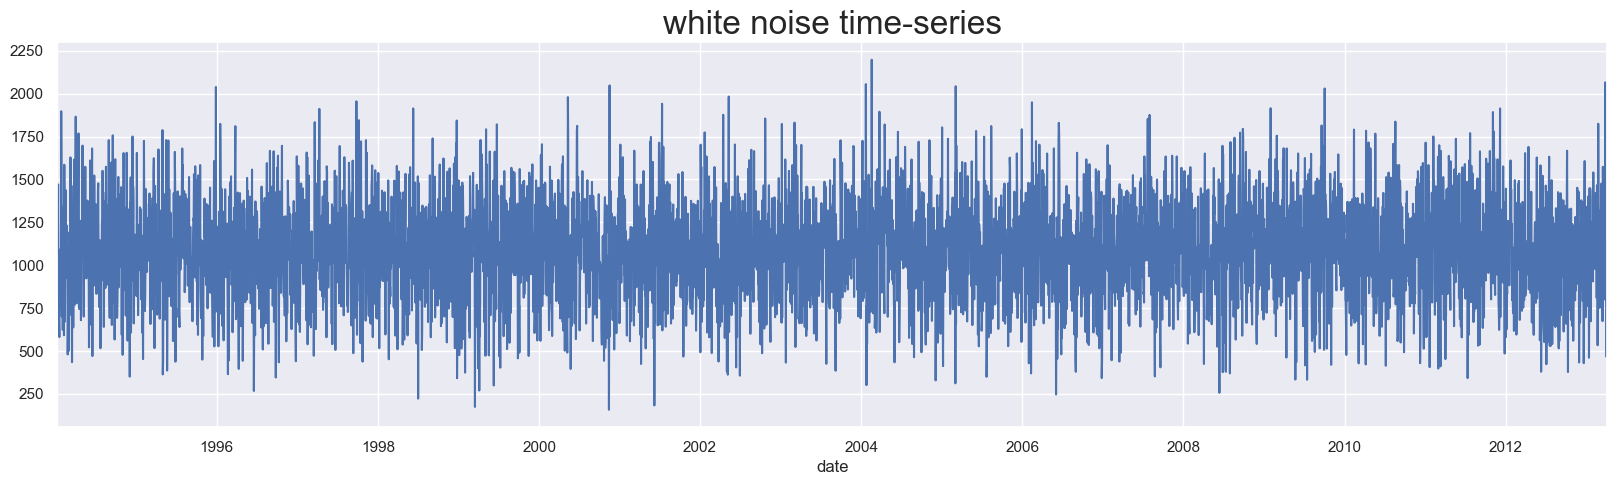

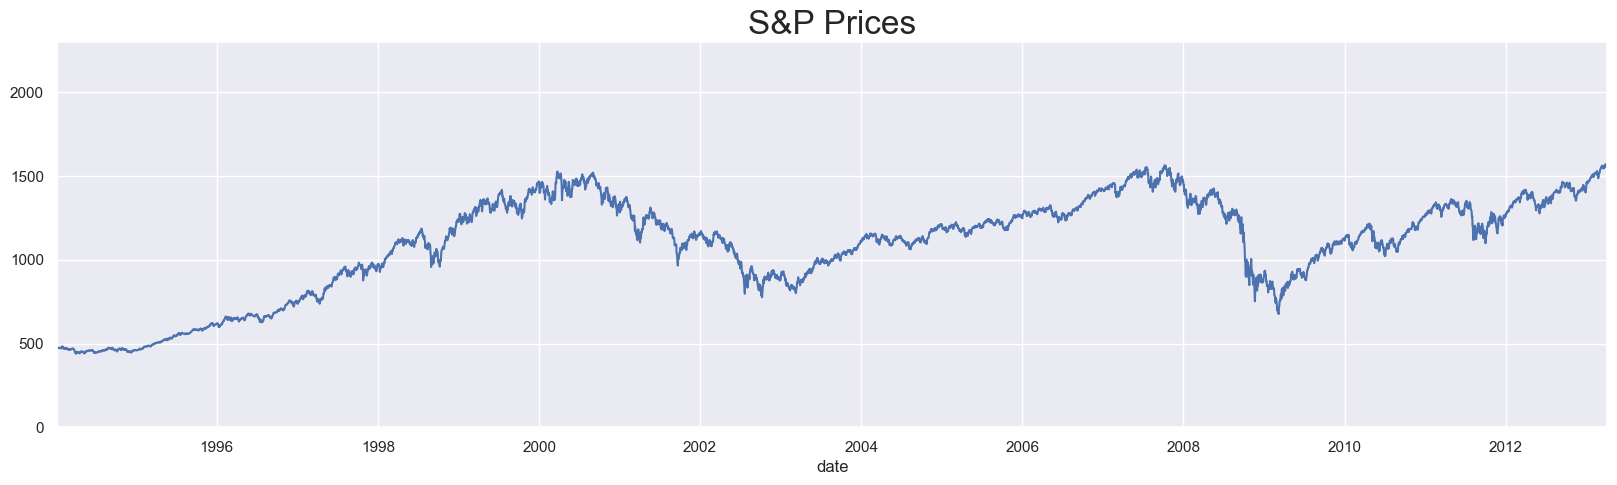

In [14]:
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
df.wn.plot(figsize=(20,5))
plt.title("white noise time-series",size=24)
plt.show()
df.market_value.plot(figsize=(20,5))
plt.title("S&P Prices",size=24)
plt.ylim(0,2300)
plt.show()

In [15]:
rw=pd.read_csv("Randwalk.csv")
rw.date=pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw=rw.asfreq('b')
rw.describe()

,price
count,5021.000000
mean,1269.944293
std,444.216793
min,585.483034
25%,931.550429
50%,1156.363045
75%,1488.362029
max,2715.508720


In [16]:
df['rw']=rw.price
df.head()

C:\Users\ysriv\AppData\Local\Temp\ipykernel_38516\3903224311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw']=rw.price


,market_value,wn,rw
date,,,
1994-01-07,469.90,1078.994033,1122.139662
1994-01-10,475.27,1365.608909,1080.347860
1994-01-11,474.13,1230.757357,1082.095245
1994-01-12,474.17,1470.542953,1083.639265
1994-01-13,472.47,864.682295,1067.146255


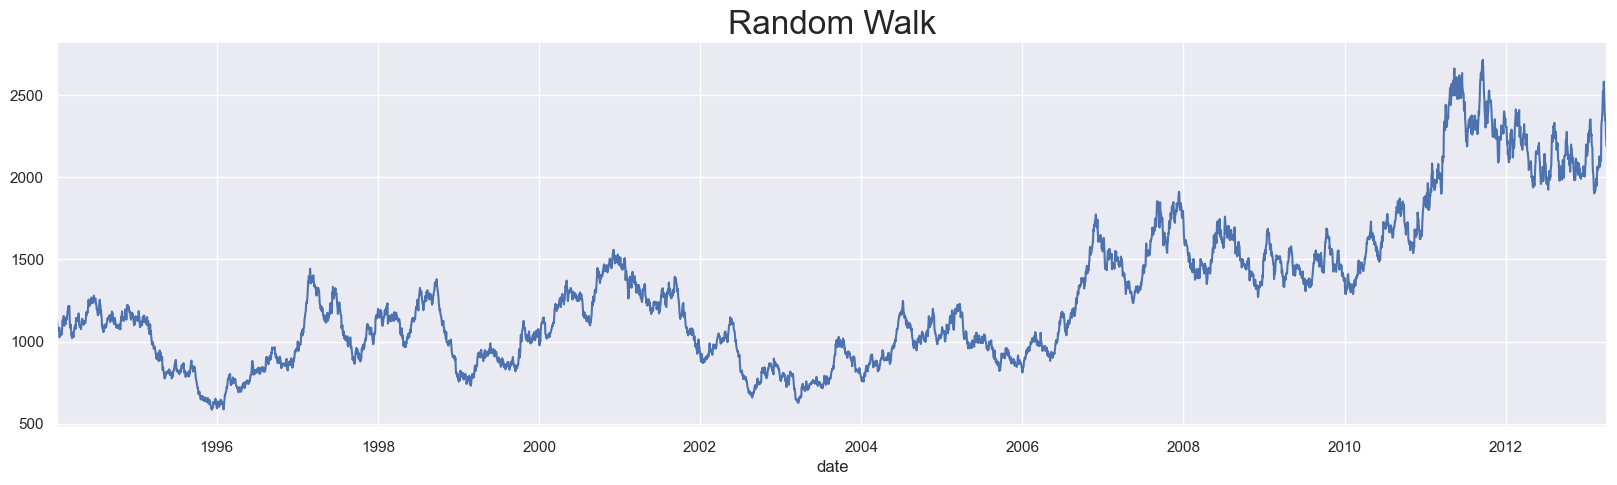

In [17]:
##plotting random walk data
df.rw.plot(figsize=(20,5))
plt.title("Random Walk",size=24)
plt.show()

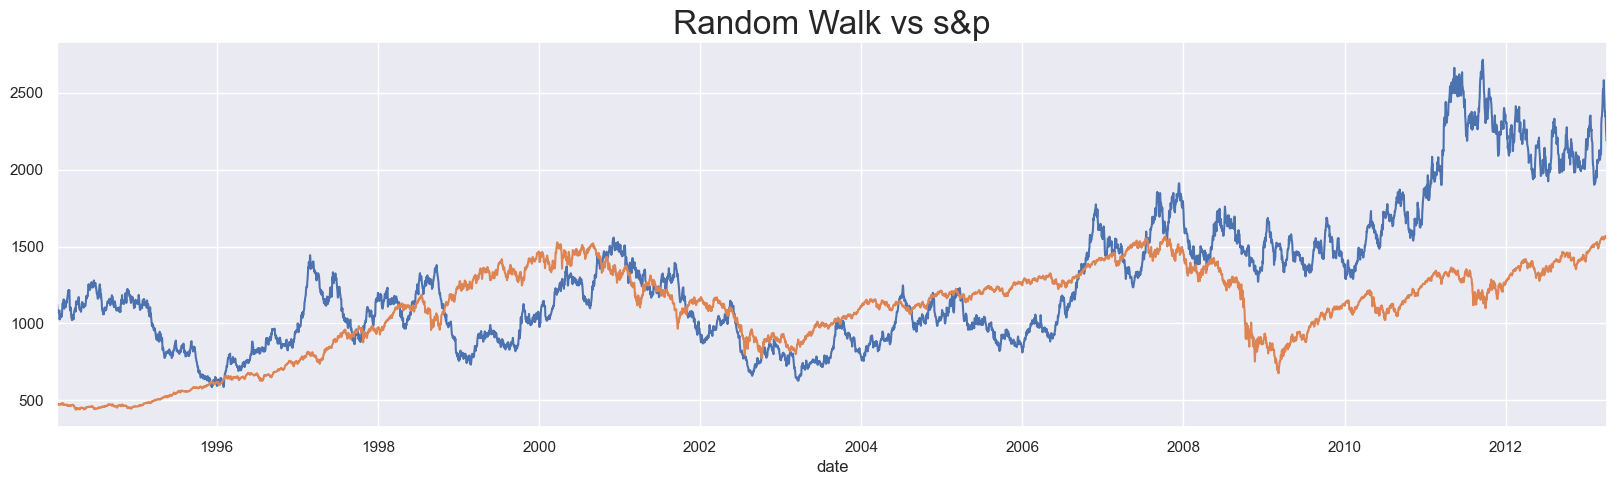

In [18]:
## plotting the spx and random walk on the same plot
df.rw.plot(figsize=(20,5))
df.market_value.plot(figsize=(20,5))
plt.title("Random Walk vs s&p",size=24)
plt.show()

# ------------------------------------------------------------------

## ***MORE DETAILED EXPLANATION***

### In baseline model section we compared different naive forecasting methods and learned that they often serve as benchmarks for more sophisticated models. However, there are instances where the simplest methods will yield the best forecasts. This is the case when we face a random walk process.

## **---1--- THE RANDOM WALK PROCESS------**

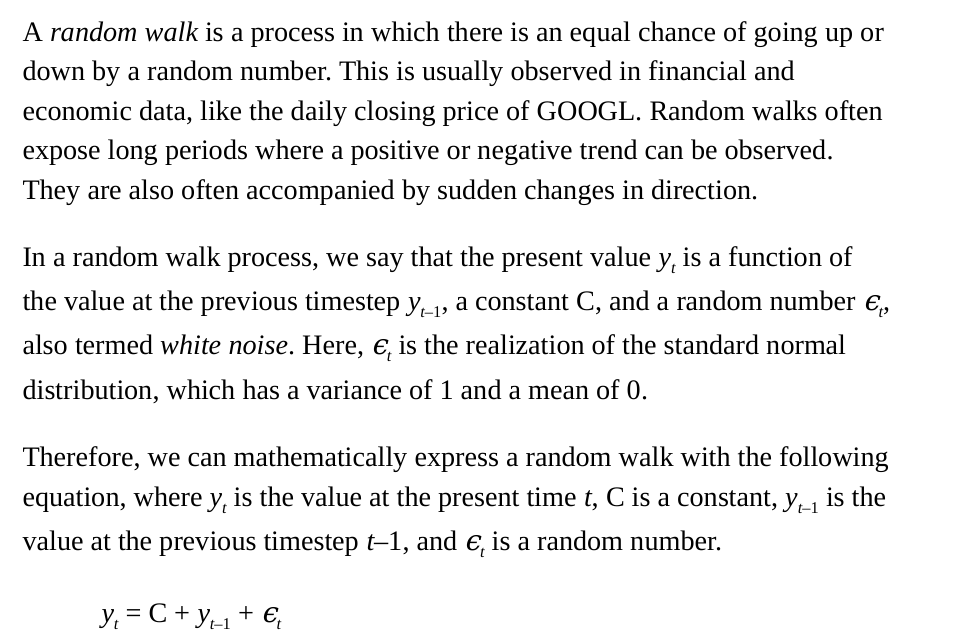

### *Note that if the constant C is nonzero, we designate this process as a randommwalk with drift.*

## **INITIALIZING C=0 and initial value i.e y0=0,we can visualize how our simulated random walk takes shape**

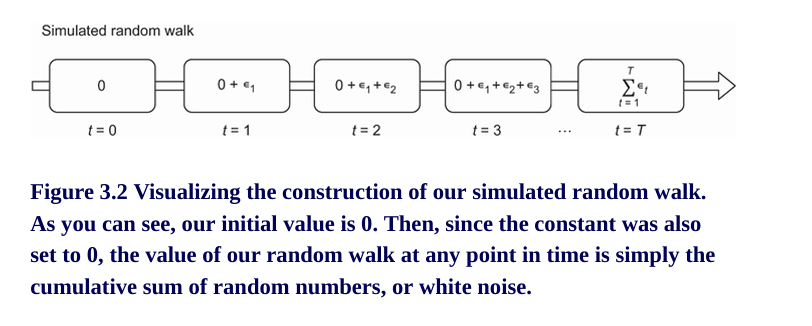

## ***----PLOTTING THE GOOGL DATA----***

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [21]:

df = pd.read_csv('GOOGL_2020-04-28_to_2021-04-27.csv',index_col=0)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
1,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
2,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
3,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600
4,2020-05-04,1333.000000,1349.459961,1323.540039,1341.329956,1341.329956,1781400


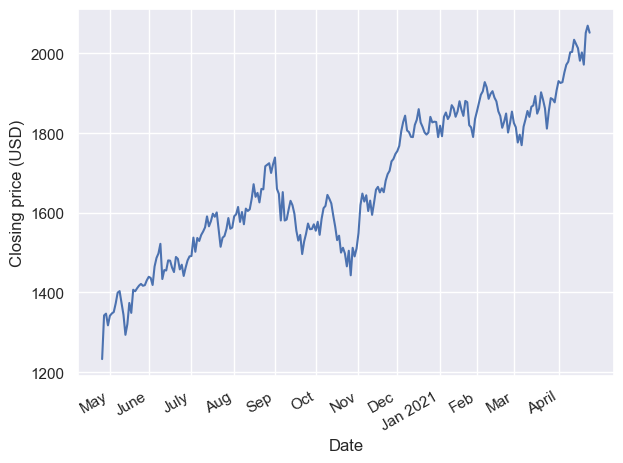

In [23]:

fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

Now we must decide on the length of our simulated process. For this exercise, we will generate 1,000 samples. The numpy library allows us to generate numbers from a normal distribution by using the standard_normal method. This ensures that the numbers come from a distribution with mean of 0, as per the definition of white noise; I’ve also given it a variance of 1 (a normal distribution). Then we can set the very first value of our series to 0. Finally, the cumsum method will calculate the cumulative sum of white noise for each timestep in our series, and we will have simulated our random walk:

In [25]:
np.random.seed(42)                            
steps = np.random.standard_normal(1000)       
steps[0]=0                                    
random_walk = np.cumsum(steps)    

## ***plotting simulated random walk***

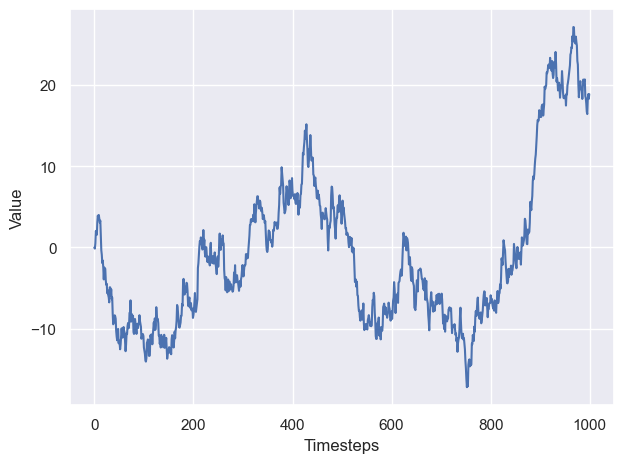

In [26]:
fig, ax = plt.subplots() 
ax.plot(random_walk) 
ax.set_xlabel('Timesteps') 
ax.set_ylabel('Value') 
plt.tight_layout()

### A simulated random walk. Notice how we have a positive trend during the first 400 timesteps, followed by a negative trend, and a sharp increase toward the end. These are good hints that we have a random walk process.

We know this is a random walk because we simulated it. However, when dealing with real-life data, we need to find a way to identify whether our time series is a random walk or not. Let’s see how we can achieve this.

## **-----Identifying a random walk-----**

## **To determine if our time series can be approximated as a random walk or not, we must first define a random walk. In the context of time series, a random walk is defined as a series whose first difference is stationary and uncorrelated.**
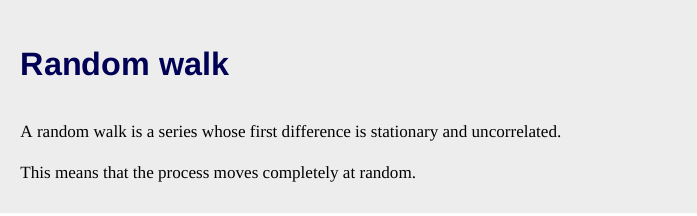

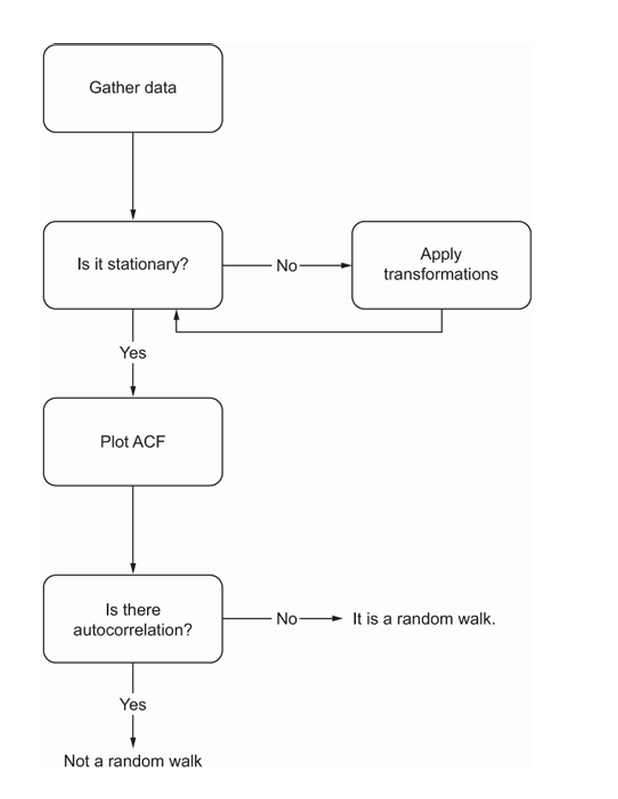
 ## ***Steps to follow to identify whether time series data can be approximated as a random walk or not. The first step is naturally to gather the data. Then we test for stationarity. If it is not stationary, we apply transformations until stationarity is achieved. Then we can plot the autocorrelation function(ACF). If there is no autocorrelation, we have a random walk.***